# Notebook 5 — Logistic Regression

Linear Regression predicts a **number**. Logistic Regression predicts a **category** — usually a class such as "yes" or "no".

We'll use the Hotel Bookings dataset.

Our goal is to predict whether a hotel booking was **Canceled** or **Not Canceled**.

### Load the Data

We'll use the Hotel Bookings dataset for all examples below.

The target variable is `is_canceled`:

- `0` = Not Canceled
- `1` = Canceled

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

data = pd.read_csv("data/hotel_bookings.csv")

data["children"] = data["children"].fillna(0)

data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 1. Classification

**Classification** means predicting a category instead of a continuous number.

In our Hotel Bookings dataset, we'll predict whether a booking was **Canceled** or **Not Canceled**.

The target variable is `is_canceled`.

In [2]:
print(data[["lead_time", "adr", "is_canceled"]].head())

   lead_time   adr  is_canceled
0        342   0.0            0
1        737   0.0            0
2          7  75.0            0
3         13  75.0            0
4         14  98.0            0


## 2. Binary Classification

**Binary Classification** means there are only **two** possible categories, usually labeled `0` and `1`.

Here:

- `0` = Not Canceled
- `1` = Canceled

Therefore, predicting `is_canceled` is a Binary Classification problem.

In [3]:
print(data["is_canceled"].value_counts())

is_canceled
0    75166
1    44224
Name: count, dtype: int64


## 3. Logistic Regression

**Logistic Regression** is a model that predicts the **probability** of a category.

We'll use `lead_time` to predict whether a booking is canceled.

The model will output a probability between 0 and 1.

In [4]:
x = data[["lead_time"]]
y = data["is_canceled"]

model = LogisticRegression(max_iter=1000)

model.fit(x, y)

print("Model trained!")

Model trained!


## 4. Sigmoid Function

The **sigmoid function** is the mathematical function behind Logistic Regression.

It takes any number and converts it into a value between 0 and 1.

This creates an S-shaped curve and allows the model to represent its output as a probability.

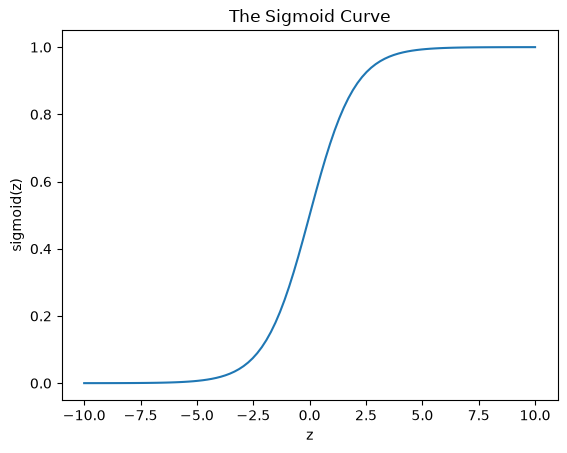

In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)

plt.plot(z, sigmoid(z))
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("The Sigmoid Curve")
plt.show()

## 5. Probability

Instead of only saying "Canceled" or "Not Canceled", Logistic Regression can tell us how likely a booking is to be canceled.

The probability is always between 0 and 1.

For example:

- `0.20` → low probability of cancellation
- `0.80` → high probability of cancellation

In [7]:
probabilities = model.predict_proba(x)[:, 1]

print("Probability of Cancellation (first 5 bookings):")
print(np.round(probabilities[:5], 2))

Probability of Cancellation (first 5 bookings):
[0.7  0.96 0.25 0.25 0.25]


## 7. Decision Boundary

The **decision boundary** is the point where the prediction changes from one class to another.

For binary Logistic Regression, the default decision boundary corresponds to a probability of `0.5`.

Below, we can see how the predicted probability changes with `lead_time`.

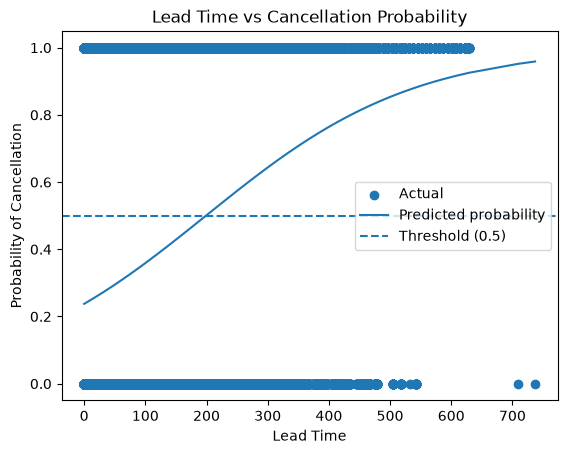

In [8]:
sorted_x = x.sort_values("lead_time")

sorted_probs = model.predict_proba(sorted_x)[:, 1]

plt.scatter(
    data["lead_time"],
    data["is_canceled"],
    label="Actual"
)

plt.plot(
    sorted_x["lead_time"],
    sorted_probs,
    label="Predicted probability"
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Threshold (0.5)"
)

plt.xlabel("Lead Time")
plt.ylabel("Probability of Cancellation")
plt.title("Lead Time vs Cancellation Probability")
plt.legend()
plt.show()

In [9]:
loss = log_loss(y, probabilities)

print("Log Loss:", round(loss, 3))

Log Loss: 0.616


## 9. Coefficients

The **coefficient** tells us how a feature affects the model's prediction.

For our model, the feature is `lead_time`.

- Positive coefficient → higher lead time increases the model's tendency toward cancellation
- Negative coefficient → higher lead time decreases the model's tendency toward cancellation

The coefficient describes the model's learned relationship and does not by itself prove causation.

In [10]:
print("Coefficient:", model.coef_[0][0])
print("Intercept:", model.intercept_[0])

Coefficient: 0.0058550011081246215
Intercept: -1.1655796379025656


## 10. Multiclass Classification

So far, we have only two classes:

- Not Canceled
- Canceled

**Multiclass Classification** is when there are **three or more** possible categories.

For example, we can create three booking lead-time categories:

- Short
- Medium
- Long

Then Logistic Regression can be used to predict which category a booking belongs to.

## 11. Why is Logistic Regression a Classification Algorithm Despite Its Name?

The name **Logistic Regression** can be confusing.

It uses a regression equation to calculate a score, but the score is passed through the **Sigmoid Function** to produce a probability between 0 and 1.

That probability is then converted into a class using a threshold.

The process is:

Input Features
↓
Linear Equation
↓
Sigmoid Function
↓
Probability
↓
Threshold
↓
Class

For example:

Probability of cancellation = `0.82`

Using a threshold of `0.5`:

`0.82 >= 0.5 → Canceled (Class 1)`

Therefore, Logistic Regression is a **classification algorithm** because its final purpose is to assign observations to classes.

It is called "Regression" because the underlying model calculates a continuous probability using a regression equation.

## Conclusion

In this notebook, we learned:

- Classification
- Binary Classification
- Logistic Regression
- Sigmoid Function
- Probability
- Threshold
- Decision Boundary
- Log Loss
- Coefficients
- Multiclass Classification

We used the Hotel Bookings dataset to predict whether a booking was canceled.

Logistic Regression is called "Regression", but it is used for classification because it converts its calculated probability into a class such as `0` or `1`.